In [1]:
import instructor
import cohere
from openai import OpenAI
from qdrant_client import QdrantClient, models
from pydantic import BaseModel, Field
from typing import List, Union, Annotated
from jinja2 import Template
from langsmith import traceable, get_current_run_tree

In [2]:

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_openai_messages, convert_to_messages
from langgraph.types import Send

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add
from openai import OpenAI

import random
import ast
import inspect
import instructor
import json

import openai

from utils.utils import get_tool_descriptions, format_ai_message, display_graph

from qdrant_client import QdrantClient
from qdrant_client import models
from qdrant_client.models import Filter, FieldCondition, MatchValue, VectorParams, Distance, SparseVectorParams, Modifier, PayloadSchemaType, PointStruct, Document, Prefetch, FusionQuery

from langsmith import traceable

In [3]:
class RAGUsedContext(BaseModel):
    id: Union[int, str] = Field(description="ID of the intervention")
    machine: str = Field(description="Machine of the intervention")
    date_start: str = Field(description="Date of the intervention")
    summary: str = Field(description="Summary of the intervention")

class RAGGenerationResponse(BaseModel):
    answer: str = Field(description="Answer to the question")
    references: List[RAGUsedContext] = Field(description="List of problems that answer the question")

In [4]:
def embed_text(text: str, openai_client: OpenAI, model: str = "text-embedding-3-small") -> list[float]:
    response = openai_client.embeddings.create(input=text, model=model)
    return response.data[0].embedding

def retrieve_data(
    client: QdrantClient,
    openai_client: OpenAI,
    collection_name: str,
    query: str,
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    top_k: int = 5,
) -> list[dict]:
    

    query_vector = embed_text(query, openai_client, embedding_model)
    search_results = client.query_points(
        collection_name=collection_name,
        prefetch=[
            models.Prefetch(query=query_vector, using=embedding_model, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + keyword_model), using=keyword_model, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]

def rerank_results(
    cohere_client: cohere.Client,
    query: str,
    results: list[dict],
    model: str = "rerank-v4.0",
    top_k: int = 5,
) -> list[dict]:
    if not results:
        return []
    contexts = [result["payload"]["summary"] for result in results]
    response = cohere_client.rerank(
        model=model, query=query, documents=contexts, top_n=top_k
    )
    return [results[res.index] for res in response.results]

@traceable(name="format_context", run_type="prompt")
def format_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += f"ID: {payload.get('id', 'N/A')}\n"
        context += f"Machine: {payload.get('machine', 'N/A')}\n"
        context += f"Date: {payload.get('date_start', 'N/A')}\n"
        context += f"Summary: {payload.get('summary', 'N/A')}\n"
        context += "-" * 40 + "\n"
    return context

def generate_answer(openai_client: OpenAI, prompt: str, model: str = "gpt-4o-mini"):
    client = instructor.patch(openai_client)
    response = client.chat.completions.create(
        model=model,
        messages=[{"role": "system", "content": prompt}],
        response_model=RAGGenerationResponse,
    )
    return response

def rag_pipeline(
    qdrant_client: QdrantClient,
    openai_client: OpenAI,
    cohere_client: cohere.Client,
    collection_name: str,
    query: str,
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    generation_model: str = "gpt-4o-mini",
    rerank_model: str = "rerank-v4.0-pro",
    top_n: int = 10,
    top_k: int = 5,
) -> dict:
    results = retrieve_data(qdrant_client, openai_client, collection_name, query, embedding_model, keyword_model, top_n)
    reranked_results = rerank_results(cohere_client, query, results, rerank_model, top_k)
    context = format_context(reranked_results)
    
    prompt_content = """You are a maintenance assistant. Use the contexts to answer the question.
Question: {{ query }}
Contexts:
{{ context }}"""
    template = Template(prompt_content)
    prompt = template.render(context=context, query=query)
    
    answer = generate_answer(openai_client, prompt, generation_model)
    
    return {
        "answer": answer.answer,
        "references": answer.references,
        "retrieved_context": context,
        "similarity_scores": [res["score"] for res in reranked_results]
    }

In [5]:
# Usage Test
openai_client = OpenAI()
cohere_client = cohere.Client()
qdrant_client = QdrantClient(host="localhost", port=6333)

collection_name = "cm_interventions_hybrid"
query = "I want all roller issues and fan problems"

response = rag_pipeline(
    qdrant_client=qdrant_client,
    openai_client=openai_client,
    cohere_client=cohere_client,
    collection_name=collection_name,
    query=query
)

print(f"Answer: {response['answer']}")

Answer: Here are the recent roller issues identified on the CB-200 machine:

1. **ID: INT-2024-0336**  
   - **Date:** 2024-05-08 07:20  
   - **Summary:** Carry roller bearing alarm B-006. Bearing failure on roller #147 due to loose electrical terminal resulting in increased vibration and grinding noise.  
   - **Action:** Roller replaced; vibration nominal post-repair.

2. **ID: INT-2022-1016**  
   - **Date:** 2022-12-13 14:58  
   - **Summary:** Carry roller bearing alarm B-006. Bearing failure on roller #28 due to bearing wear.  
   - **Action:** Roller replaced; permanent repair scheduled.

3. **ID: INT-2023-0070**  
   - **Date:** 2023-01-22 22:15  
   - **Summary:** Carry roller bearing alarm B-006. Bearing failure on roller #142 due to drive belt elongation.  
   - **Action:** Roller replaced; monitoring frequency increased.

4. **ID: INT-2022-0002**  
   - **Date:** 2022-01-01 07:24  
   - **Summary:** Carry roller bearing alarm B-006. Bearing failure on roller #36 due to enc

## Query Expansion - Sequential

In [6]:
class QueryExpandResponseSequential(BaseModel):
    statements: List[str]

In [7]:
def query_expansion_node(query) -> dict:

    prompt_template = """You are a query expansion module for a maintenance assistant. Your job is to rewrite a technician's query into distinct semantic statements to search past intervention logs.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should focus on a specific machine, component, or symptom.
    - Use technical maintenance terminology (e.g., 'abnormal vibration', 'hydraulic leak').
    - Do not produce redundant statements.

    ## Examples

    Question: "The conveyor motor is smoking and making a grinding noise"
    Statements:
    - "Conveyor motor overheating and smoke symptom"
    - "Motor bearing grinding noise"

    Question: "Check history of machine 307 valve issues"
    Statements:
    - "Machine 307 maintenance history"
    - "Hydraulic valve failure logs"

    Question: "How to fix a sensor error on line 4?"
    Statements:
    - "Line 4 sensor calibration and repair"
    - "Optical sensor fault code troubleshooting"

    <question>
    {{ query }}
    </question>
    """
    template = Template(prompt_template)
    prompt = template.render(query=query)

    client = instructor.from_provider("openai/gpt-4o-mini")
    response, raw_response = client.create_with_completion(
        messages=[{'role': 'system', "content": prompt}],
        response_model=QueryExpandResponseSequential
    )
    return {"queries": response.statements}

In [16]:
class QueryExpandResponse(BaseModel):
    statements: List[str]

## LangGraph 

In [8]:
from operator import add
from pydantic import BaseModel

class State(BaseModel):
    expanded_query: List[str] = []
    retrieved_contexts: Annotated[List[str], add] = []
    initial_query: str = ""
    answer: str = ""


In [9]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module for a maintenance assistant. Your job is to rewrite a technician's query into distinct semantic statements to search past intervention logs.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should focus on a specific machine, component, or symptom.
    - Use technical maintenance terminology (e.g., 'abnormal vibration', 'hydraulic leak').
    - Do not produce redundant statements.

    ## Examples

    Question: "The conveyor motor is smoking and making a grinding noise"
    Statements:
    - "Conveyor motor overheating and smoke symptom"
    - "Motor bearing grinding noise"

    Question: "Check history of machine 307 valve issues"
    Statements:
    - "Machine 307 maintenance history"
    - "Hydraulic valve failure logs"

    Question: "How to fix a sensor error on line 4?"
    Statements:
    - "Line 4 sensor calibration and repair"
    - "Optical sensor fault code troubleshooting"

    <question>
    {{ query }}
    </question>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_provider("openai/gpt-4.1-mini")
    response, raw_response = client.create_with_completion(
        messages=[{'role': 'system', "content": prompt}],
        response_model=QueryExpandResponse
    )
    return {"expanded_query": response.statements}


### Retriever Node

In [10]:
@traceable(name="embed_query", run_type="embedding")
def embed_text(text: str, openai_client: OpenAI, model: str = "text-embedding-3-small") -> list[float]:
    response = openai_client.embeddings.create(input=text, model=model)
    return response.data[0].embedding

@traceable(name="data_retrieval", run_type="retriever")
def retrieve_data(
    client: QdrantClient,
    openai_client: OpenAI,
    query: str,
    collection_name: str = "cm_interventions_hybrid",
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    top_k: int = 5,
) -> list[dict]:
    query_vector = embed_text(query, openai_client, embedding_model)
    search_results = client.query_points(
        collection_name=collection_name,
        prefetch=[
            models.Prefetch(query=query_vector, using=embedding_model, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + keyword_model), using=keyword_model, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]

@traceable(name="reranking", run_type="retriever")
def rerank_results(
    cohere_client: cohere.Client,
    query: str,
    results: list[dict],
    model: str = "rerank-v4.0-pro",
    top_k: int = 5,
) -> list[dict]:
    if not results:
        return []
    contexts = [result["payload"]["summary"] for result in results]
    response = cohere_client.rerank(model=model, query=query, documents=contexts, top_n=top_k)
    return [results[res.index] for res in response.results]

@traceable(name="format_context", run_type="prompt")
def format_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += f"ID: {payload.get('id', 'N/A')}\nMachine: {payload.get('machine', 'N/A')}\nDate: {payload.get('date_start', 'N/A')}\nSummary: {payload.get('summary', 'N/A')}\n" + "-" * 40 + "\n"
    return context

@traceable(name="retrieve_rerank", run_type="retriever")
def retrieve_rerank(
    qdrant_client: QdrantClient,
    openai_client: OpenAI,
    cohere_client: cohere.Client,
    query: str,
    collection_name: str = "cm_interventions_hybrid",
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    rerank_model: str = "rerank-v4.0-pro",
    top_n: int = 10,
    top_k: int = 5,
) -> str:
    results = retrieve_data(qdrant_client, openai_client, query)
    reranked_results = rerank_results(cohere_client, query, results)
    context = format_context(reranked_results)
    return context


In [11]:
@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:
    retrieved_contexts = []
    for query in state.expanded_query:
        retrieved_context = retrieve_rerank(qdrant_client, openai_client, cohere_client, query=query)
        retrieved_contexts.append(retrieved_context)
    return {"retrieved_contexts": retrieved_contexts}


### Aggregator Node

In [12]:
class AggregatorResponse(BaseModel):
    answer: str


In [13]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_contexts)

    prompt_content = """You are a maintenance assistant. Use the contexts to answer the question.
    Question: {{ query }}
    Contexts:
    {{ context }}"""
    template = Template(prompt_content)
    prompt = template.render(context=preprocessed_context, query=state.initial_query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=AggregatorResponse
    )
 
    return {
        "answer": response.answer
    }


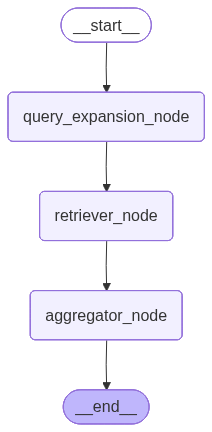

In [14]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_edge("query_expansion_node", "retriever_node")
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display_graph(graph)


In [17]:
query = "The hydraulic pump on the HX-350 is losing efficiency and I'm also seeing a valve overhaul scheduled."
initial_state = {
    "initial_query": query
}

result = graph.invoke(initial_state)


In [18]:
print(result["answer"])


The hydraulic pump on the HX-350 is losing efficiency, which is mentioned as root cause in various similar faults from other machines where the volumetric efficiency is declining below acceptable threshold due to pump internal wear. Regarding the valve overhaul, there is a related intervention for the HX-350 dated 2024-08-28: the PRV-302 relief valve was observed venting to tank due to the component reaching the end of its expected service life, with the set point being much lower than the spec. The valve was adjusted and a full test run done before resuming production. The set point was verified at spec with a calibrated gauge and inspection intervals were increased.

In summary, the hydraulic pump's loss in efficiency is likely due to internal wear requiring monitoring or replacement, and the valve overhaul aligns with the scheduled replacement of the relief valve PRV-302 which is overdue and critical to maintain proper pressure settings.


## Query Expansion - Parallel

In [19]:
from operator import add
from pydantic import BaseModel

class ExpandedQuery(BaseModel):
    query: str = Field(description="A semantic search statement derived from the original question")
    top_k: int = Field(description="Number of results to retrieve for this query (1-10), based on how specific or broad it is")

class QueryExpandResponse(BaseModel):
    statements: List[ExpandedQuery]

class State(BaseModel):
    expanded_query: List[ExpandedQuery] = []
    retrieved_contexts: Annotated[List[str], add] = []
    initial_query: str = ""
    query: str = ""
    answer: str = ""
    top_k: int = 5


In [20]:
@traceable(
    name="query_expansion",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def query_expansion_node(state: State) -> dict:
    prompt_template = """You are a query expansion module for a maintenance assistant. Your job is to rewrite a technician's query into distinct semantic statements to search past intervention logs.

    ## Instructions

    - Expand the question into 1-5 concise statements.
    - Each statement should focus on a specific machine, component, or symptom.
    - Use technical maintenance terminology (e.g., 'abnormal vibration', 'hydraulic leak').
    - Do not produce redundant statements.
    - For each statement, also assign a top_k (1-10): use higher values for broad queries, lower for specific ones.

    ## Examples

    Question: "The conveyor motor is smoking and making a grinding noise"
    Statements:
    - query: "Conveyor motor overheating and smoke symptom", top_k: 3
    - query: "Motor bearing grinding noise", top_k: 3

    Question: "Check history of machine 307 valve issues"
    Statements:
    - query: "Machine 307 maintenance history", top_k: 8
    - query: "Hydraulic valve failure logs", top_k: 5

    Question: "How to fix a sensor error on line 4?"
    Statements:
    - query: "Line 4 sensor calibration and repair", top_k: 4
    - query: "Optical sensor fault code troubleshooting", top_k: 4

    <question>
    {{ query }}
    </question>
    """
    template = Template(prompt_template)
    prompt = template.render(query=state.initial_query)
    client = instructor.from_provider("openai/gpt-4.1-mini")
    response, raw_response = client.create_with_completion(
        messages=[{'role': 'system', "content": prompt}],
        response_model=QueryExpandResponse
    )
    return {"expanded_query": response.statements}


### Retriever Node

In [21]:
@traceable(name="embed_query", run_type="embedding")
def embed_text(text: str, openai_client: OpenAI, model: str = "text-embedding-3-small") -> list[float]:
    response = openai_client.embeddings.create(input=text, model=model)
    return response.data[0].embedding

@traceable(name="data_retrieval", run_type="retriever")
def retrieve_data(
    client: QdrantClient,
    openai_client: OpenAI,
    query: str,
    collection_name: str = "cm_interventions_hybrid",
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    top_k: int = 5,
) -> list[dict]:
    query_vector = embed_text(query, openai_client, embedding_model)
    search_results = client.query_points(
        collection_name=collection_name,
        prefetch=[
            models.Prefetch(query=query_vector, using=embedding_model, limit=top_k // 2),
            models.Prefetch(query=models.Document(text=query, model="qdrant/" + keyword_model), using=keyword_model, limit=top_k // 2),
        ],
        query=models.RrfQuery(rrf=models.Rrf(weights=[1, 1])),
        limit=top_k,
    ).points
    return [{"id": point.id, "payload": point.payload, "score": point.score} for point in search_results]

@traceable(name="reranking", run_type="retriever")
def rerank_results(
    cohere_client: cohere.Client,
    query: str,
    results: list[dict],
    model: str = "rerank-v4.0-pro",
    top_k: int = 5,
) -> list[dict]:
    if not results:
        return []
    contexts = [result["payload"]["summary"] for result in results]
    response = cohere_client.rerank(model=model, query=query, documents=contexts, top_n=top_k)
    return [results[res.index] for res in response.results]

@traceable(name="format_context", run_type="prompt")
def format_context(results: list[dict]) -> str:
    context = ""
    for result in results:
        payload = result["payload"]
        context += f"ID: {payload.get('id', 'N/A')}\nMachine: {payload.get('machine', 'N/A')}\nDate: {payload.get('date_start', 'N/A')}\nSummary: {payload.get('summary', 'N/A')}\n" + "-" * 40 + "\n"
    return context

@traceable(name="retrieve_rerank", run_type="retriever")
def retrieve_rerank(
    qdrant_client: QdrantClient,
    openai_client: OpenAI,
    cohere_client: cohere.Client,
    query: str,
    collection_name: str = "cm_interventions_hybrid",
    embedding_model: str = "text-embedding-3-small",
    keyword_model: str = "bm25",
    rerank_model: str = "rerank-v4.0-pro",
    top_n: int = 10,
    top_k: int = 5,
) -> str:
    results = retrieve_data(qdrant_client, openai_client, query, top_k=top_n)
    reranked_results = rerank_results(cohere_client, query, results, top_k=top_k)
    context = format_context(reranked_results)
    return context


In [22]:
@traceable(
    name="retriever_node",
    run_type="retriever"
)
def retriever_node(state: State) -> dict:
    retrieved_context = retrieve_rerank(qdrant_client, openai_client, cohere_client, query=state.query, top_k=state.top_k)
    return {"retrieved_contexts": [retrieved_context]}

def parallel_retriever(state: State) -> list[Send]:
    return [
        Send("retriever_node", State(query=eq.query, initial_query=state.initial_query, top_k=eq.top_k))
        for eq in state.expanded_query
    ]


### Aggregator Node

In [23]:
class AggregatorResponse(BaseModel):
    answer: str


In [24]:
@traceable(
    name="generate_answer",
    run_type="llm",
    metadata={"ls_provider": "openai", "ls_model_name": "gpt-4.1-mini"}
)
def aggregator_node(state: State) -> dict:

    preprocessed_context = "\n".join(state.retrieved_contexts)

    prompt_content = """You are a maintenance assistant. Use the contexts to answer the question.
    Question: {{ query }}
    Contexts:
    {{ context }}"""
    template = Template(prompt_content)
    prompt = template.render(context=preprocessed_context, query=state.initial_query)

    client = instructor.from_provider(
        "openai/gpt-4.1-mini"
    )

    response, raw_response = client.create_with_completion(
        messages=[
            {"role": "system", "content": prompt}
        ],
        response_model=AggregatorResponse
    )
 
    return {
        "answer": response.answer
    }


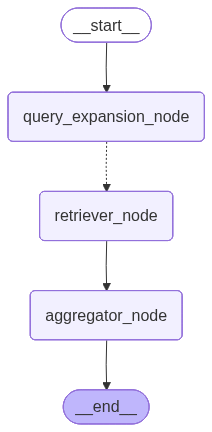

In [25]:
workflow = StateGraph(State)
workflow.add_node("query_expansion_node", query_expansion_node)
workflow.add_node("retriever_node", retriever_node)
workflow.add_node("aggregator_node", aggregator_node)

workflow.add_edge(START, "query_expansion_node")
workflow.add_conditional_edges("query_expansion_node", parallel_retriever, ["retriever_node"])
workflow.add_edge("retriever_node", "aggregator_node")
workflow.add_edge("aggregator_node", END)

graph = workflow.compile()
display_graph(graph)


In [26]:
query = "The hydraulic pump on the HX-350 is losing efficiency and I'm also seeing a valve overhaul scheduled."
initial_state = {
    "initial_query": query
}

result = graph.invoke(initial_state)


In [27]:
print(result["answer"])


The HX-350 hydraulic pump issue involves a decline in volumetric efficiency due to pump internal wear, as indicated in inspection ID INT-2023-0195. The valve overhaul appears related to the PRV-302 relief valve noted in ID INT-2024-0679, where the valve was venting to the tank, pressure spike was recorded, and it was found that the valve was reaching the end of its service life with a set point issue. The valve overhaul or adjustment has been performed to restore proper function.

In summary, the hydraulic pump efficiency loss is due to internal wear of the pump, which has been addressed in the past by cleaning and recalibration or replacement. The valve overhaul scheduled is related to the PRV-302 relief valve, which is overdue for replacement or overhaul due to lifecycle wear. Both issues are consistent with routine wear and scheduled maintenance tasks to restore and maintain machine performance.


In [28]:
result

{'expanded_query': [ExpandedQuery(query='Hydraulic pump efficiency loss on HX-350', top_k=5),
  ExpandedQuery(query='Valve overhaul maintenance schedule on HX-350', top_k=3)],
 'retrieved_contexts': ['ID: INT-2022-0079\nMachine: IH-300\nDate: 2022-02-02 06:28\nSummary: [FAULT_CODE] H-003\n[EVENT] Coil cooling flow fault H-003. Flow meter COILFL-101 reading 153 L/min. System stopped to protect hardening coil.\n[COMMENTS] Fault H-003: coil cooling flow 153 L/min (minimum 4 L/min). Root cause: pump internal wear — volumetric efficiency declining below acceptable threshold. Component cleaned and recalibrated. Monitoring frequency increased for next 30 days. Flow restored to 55 L/min. Coil inspected — no thermal damage. Oil sample sent to lab — results pending.\n----------------------------------------\nID: INT-2022-0937\nMachine: IH-300\nDate: 2022-11-16 08:48\nSummary: [FAULT_CODE] H-002\n[EVENT] Power factor low alarm H-002. PF-101 reading 135 (minimum 0.85) during hardening cycle.\n[COM